Dataset Saved Successfully

Missing Values
CustomerID           0
Age                  0
SubscriptionType     0
MonthlyCharges       0
TenureMonths         0
SupportTickets       0
SatisfactionScore    0
UsageHoursPerWeek    0
Churn                0
dtype: int64

Churn Distribution
Churn
0    2605
1     395
Name: count, dtype: int64

Average Satisfaction Score
Churn
0    5.882917
1    3.215190
Name: SatisfactionScore, dtype: float64

Subscription Wise Churn
SubscriptionType
0    0.126078
1    0.115839
2    0.145794
Name: Churn, dtype: float64


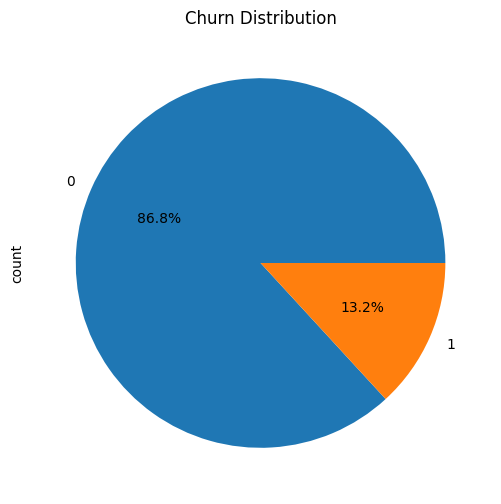

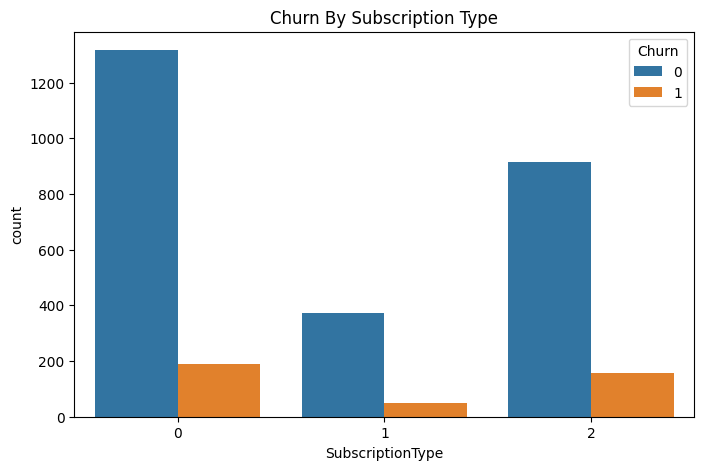

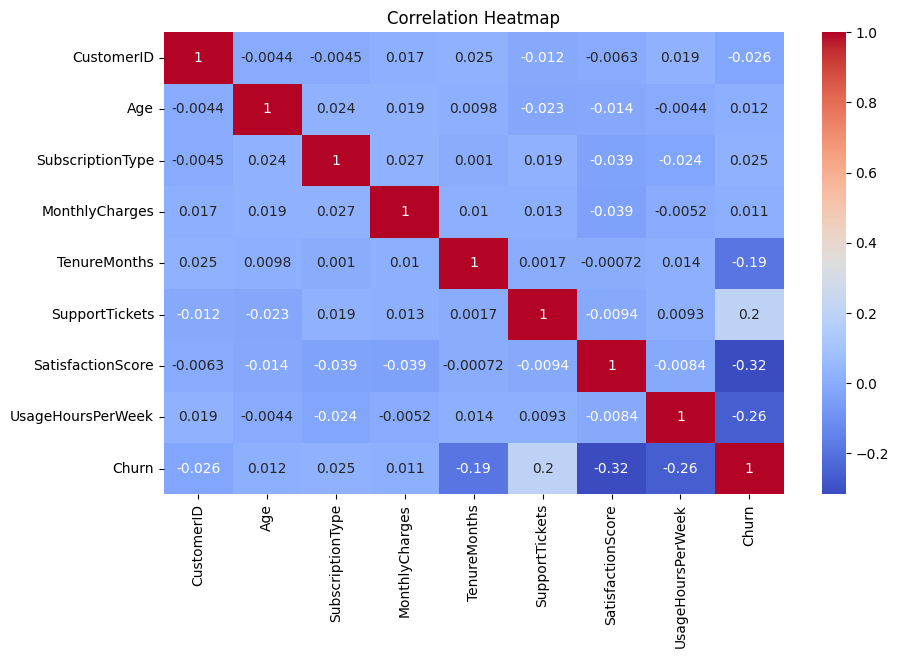

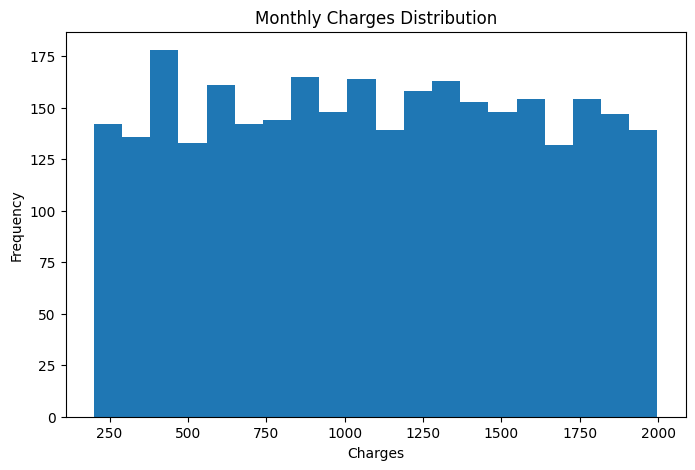


Model Evaluation
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Confusion Matrix
[[524   0]
 [  0  76]]

===== Customer Churn Prediction =====
Enter Age: 25
Subscription Type (0-Basic, 1-Enterprise, 2-Premium): 0
Monthly Charges: 541
Tenure Months: 23
Support Tickets: 21
Satisfaction Score (1-10): 4
Usage Hours Per Week: 32

Customer Likely To Churn


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

# DATASET GENERATION

np.random.seed(42)
n = 3000
customer_id = np.arange(1001, 1001 + n)
age = np.random.randint(18, 65, n)
subscription = np.random.choice(
    ['Basic', 'Premium', 'Enterprise'],
    n,
    p=[0.5, 0.35, 0.15]
)
monthly_charges = np.random.randint(
    200,
    2000,
    n
)
tenure = np.random.randint(
    1,
    60,
    n
)
support_tickets = np.random.poisson(
    3,
    n
)
satisfaction = np.random.randint(
    1,
    11,
    n
)
usage = np.random.randint(
    1,
    40,
    n
)

# CHURN LOGIC

churn = []
for i in range(n):
    score = 0
    if satisfaction[i] <= 4:
        score += 4
    if usage[i] < 8:
        score += 3
    if support_tickets[i] > 5:
        score += 3
    if tenure[i] < 6:
        score += 3
    if subscription[i] == 'Basic':
        score += 1
    if score >= 6:
        churn.append('Yes')
    else:
        churn.append('No')

# CREATE DATAFRAME

df = pd.DataFrame({
    'CustomerID': customer_id,
    'Age': age,
    'SubscriptionType': subscription,
    'MonthlyCharges': monthly_charges,
    'TenureMonths': tenure,
    'SupportTickets': support_tickets,
    'SatisfactionScore': satisfaction,
    'UsageHoursPerWeek': usage,
    'Churn': churn
})

# SAVE DATASET

df.to_csv(
    "customer_churn_dataset.csv",
    index=False
)
print("Dataset Saved Successfully")

# PREPROCESSING

print("\nMissing Values")
print(df.isnull().sum())
df.drop_duplicates(inplace=True)
encoder = LabelEncoder()
for col in [
    'SubscriptionType',
    'Churn'
]:
    df[col] = encoder.fit_transform(df[col])

# EDA

print("\nChurn Distribution")
print(df['Churn'].value_counts())
print("\nAverage Satisfaction Score")
print(
    df.groupby('Churn')['SatisfactionScore'].mean()
)
print("\nSubscription Wise Churn")
print(
    df.groupby('SubscriptionType')['Churn'].mean()
)

# PIE CHART

plt.figure(figsize=(6, 6))
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Churn Distribution")
plt.show()

# BAR CHART

plt.figure(figsize=(8, 5))
sns.countplot(
    x='SubscriptionType',
    hue='Churn',
    data=df
)
plt.title("Churn By Subscription Type")
plt.show()

# HEATMAP

plt.figure(figsize=(10, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

# HISTOGRAM

plt.figure(figsize=(8, 5))
plt.hist(
    df['MonthlyCharges'],
    bins=20
)
plt.title("Monthly Charges Distribution")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

# MACHINE LEARNING

X = df.drop(
    ['CustomerID', 'Churn'],
    axis=1
)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(
    X_train,
    y_train
)
y_pred = model.predict(X_test)

# EVALUATION

print("\nModel Evaluation")
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)
print(
    "Precision:",
    precision_score(y_test, y_pred)
)
print(
    "Recall:",
    recall_score(y_test, y_pred)
)
print(
    "F1 Score:",
    f1_score(y_test, y_pred)
)
print(
    "\nConfusion Matrix"
)
print(
    confusion_matrix(y_test, y_pred)
)

# INTERACTIVE PREDICTION

print("\n===== Customer Churn Prediction =====")
try:
    age = int(input("Enter Age: "))
    subscription = int(input("Subscription Type (0-Basic, 1-Enterprise, 2-Premium): "))
    charges = float(input("Monthly Charges: "))
    tenure = int(input("Tenure Months: "))
    tickets = int(input("Support Tickets: "))
    satisfaction = int(input("Satisfaction Score (1-10): "))
    usage = float(input("Usage Hours Per Week: "))
    sample = pd.DataFrame([{
    'Age': age,
    'SubscriptionType': subscription,
    'MonthlyCharges': charges,
    'TenureMonths': tenure,
    'SupportTickets': tickets,
    'SatisfactionScore': satisfaction,
    'UsageHoursPerWeek': usage
}])
    result = model.predict(sample)
    if result[0] == 1:
        print("\nCustomer Likely To Churn")
    else:
        print("\nCustomer Likely To Stay")
except ValueError:
    print("Invalid Input")